In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


In [2]:
evaluations = pd.read_csv('data/extrait_eval.csv')
evaluations.head()


,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


In [3]:
evaluations.shape

(1470, 10)

In [4]:
employes = pd.read_csv('data/extrait_sirh.csv')
employes.head()


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [5]:
employes.shape

(1470, 12)

In [6]:
sondage = pd.read_csv('data/extrait_sondage.csv')
sondage.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [7]:
sondage.shape

(1470, 12)

In [8]:
combined = pd.concat([evaluations, employes, sondage], axis=0)
combined.reset_index(drop=True, inplace=True)
combined.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,...,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,2.0,3.0,2.0,4.0,1.0,1.0,E_1,3.0,Oui,11 %,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.0,2.0,2.0,2.0,4.0,3.0,E_2,4.0,Non,23 %,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,2.0,1.0,3.0,2.0,3.0,E_4,3.0,Oui,15 %,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,3.0,1.0,3.0,3.0,3.0,E_5,3.0,Oui,11 %,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,3.0,1.0,2.0,4.0,3.0,E_7,3.0,Non,12 %,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# -------------------------------
# 1) Nettoyage eval_number → id_employee
# -------------------------------

eval = evaluations.copy()

eval["id_employee"] = (
    eval["eval_number"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype("Int64")
)

print(">>> Aperçu conversion eval_number → id_employee :")
print(eval[["eval_number", "id_employee"]].head(), "\n")

# Vérification : identifiants valides
missing_eval_ids = set(eval["id_employee"]) - set(employes["id_employee"])
print("IDs dans eval absents de employes :", missing_eval_ids, "\n")


# -------------------------------
# 2) MERGE employes ↔ eval
# -------------------------------
merged = employes.merge(
    eval,
    on="id_employee",
    how="inner",
    suffixes=("_emp", "_eval")
)
print("Après merge employes + eval :", merged.shape)


# -------------------------------
# 3) MERGE avec sondage
# -------------------------------
missing_survey_ids = set(sondage["code_sondage"]) - set(employes["id_employee"])
print("IDs dans sondage absents de employes :", missing_survey_ids, "\n")

merged = merged.merge(
    sondage,
    left_on="id_employee",
    right_on="code_sondage",
    how="inner",
    suffixes=("", "_sondage")
)

print("Après merge complet :", merged.shape)


# -------------------------------
# 4) Nettoyage colonnes redondantes
# -------------------------------
for col in ["eval_number", "code_sondage"]:
    if col in merged.columns:
        merged.drop(columns=col, inplace=True)

print("\nColonnes finales :", len(merged.columns))
print("Liste colonnes :", merged.columns.tolist(), "\n")

merged.head()

>>> Aperçu conversion eval_number → id_employee :
  eval_number  id_employee
0         E_1            1
1         E_2            2
2         E_4            4
3         E_5            5
4         E_7            7 

IDs dans eval absents de employes : set() 

Après merge employes + eval : (1470, 22)
IDs dans sondage absents de employes : set() 

Après merge complet : (1470, 34)

Colonnes finales : 32
Liste colonnes : ['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente', 'a_quitte_l_entreprise', 'nombre_par

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,...,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,...,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,...,0,3,1,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,...,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,...,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [10]:
merged.info()
merged.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   id_employee                                1470 non-null   int64 
 1   age                                        1470 non-null   int64 
 2   genre                                      1470 non-null   object
 3   revenu_mensuel                             1470 non-null   int64 
 4   statut_marital                             1470 non-null   object
 5   departement                                1470 non-null   object
 6   poste                                      1470 non-null   object
 7   nombre_experiences_precedentes             1470 non-null   int64 
 8   nombre_heures_travailless                  1470 non-null   int64 
 9   annee_experience_totale                    1470 non-null   int64 
 10  annees_dans_l_entreprise            

id_employee  age  genre  revenu_mensuel  statut_marital  departement  poste                   nombre_experiences_precedentes  nombre_heures_travailless  annee_experience_totale  annees_dans_l_entreprise  annees_dans_le_poste_actuel  satisfaction_employee_environnement  note_evaluation_precedente  niveau_hierarchique_poste  satisfaction_employee_nature_travail  satisfaction_employee_equipe  satisfaction_employee_equilibre_pro_perso  note_evaluation_actuelle  heure_supplementaires  augementation_salaire_precedente  a_quitte_l_entreprise  nombre_participation_pee  nb_formations_suivies  nombre_employee_sous_responsabilite  distance_domicile_travail  niveau_education  domaine_etude            ayant_enfants  frequence_deplacement  annees_depuis_la_derniere_promotion  annes_sous_responsable_actuel
1            41   F      5993            Célibataire     Commercial   Cadre Commercial        8                               80                         8                        6                  

In [11]:
merged.describe(include='all')

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.000000,1470.000000,1470,1470.000000,1470,1470,1470,1470.000000,1470.0,1470.000000,...,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470,1470,1470,1470.000000,1470.000000
unique,NaN,NaN,2,NaN,3,3,9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6,1,3,NaN,NaN
top,NaN,NaN,M,NaN,Marié(e),Consulting,Cadre Commercial,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Infra & Cloud,Y,Occasionnel,NaN,NaN
freq,NaN,NaN,882,NaN,673,961,326,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,606,1470,1043,NaN,NaN
mean,1024.865306,36.923810,NaN,6502.931293,NaN,NaN,NaN,2.693197,80.0,11.279592,...,0.793878,2.799320,1.0,9.192517,2.912925,NaN,NaN,NaN,2.187755,4.123129
std,602.024335,9.135373,NaN,4707.956783,NaN,NaN,NaN,2.498009,0.0,7.780782,...,0.852077,1.289271,0.0,8.106864,1.024165,NaN,NaN,NaN,3.222430,3.568136
min,1.000000,18.000000,NaN,1009.000000,NaN,NaN,NaN,0.000000,80.0,0.000000,...,0.000000,0.000000,1.0,1.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
25%,491.250000,30.000000,NaN,2911.000000,NaN,NaN,NaN,1.000000,80.0,6.000000,...,0.000000,2.000000,1.0,2.000000,2.000000,NaN,NaN,NaN,0.000000,2.000000
50%,1020.500000,36.000000,NaN,4919.000000,NaN,NaN,NaN,2.000000,80.0,10.000000,...,1.000000,3.000000,1.0,7.000000,3.000000,NaN,NaN,NaN,1.000000,3.000000
75%,1555.750000,43.000000,NaN,8379.000000,NaN,NaN,NaN,4.000000,80.0,15.000000,...,1.000000,3.000000,1.0,14.000000,4.000000,NaN,NaN,NaN,3.000000,7.000000


In [12]:
merged.columns


Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'distance_domicile_travail', 'niveau_education', 'domaine_etude',
       'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='object')

In [13]:
print(merged.columns.tolist())
print(merged.dtypes)
df = merged.copy()

['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente', 'a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']
id_employee                                   int64
age                                           int64
genre                                        object
re

In [14]:
df.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'distance_domicile_travail', 'niveau_education', 'domaine_etude',
       'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='object')

Target distribution :
a_quitte_l_entreprise
0    1233
1     237
Name: count, dtype: int64
Shape X : (1470, 33)
Shape y : (1470,)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=300; total time=   0.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=300; total time=   0.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=300; total time=   0.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=300; total time=   0.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=300; total time=   0.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=10, n_estimators=300; total time=   0.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END 

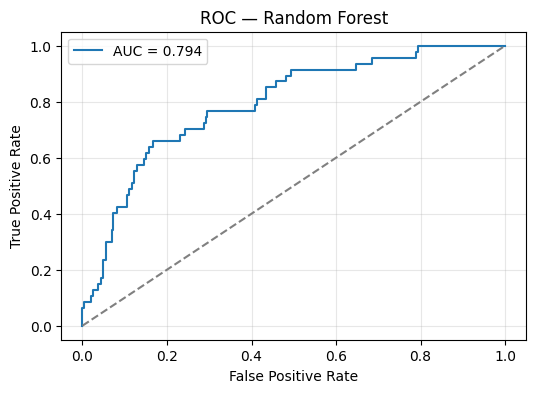

In [15]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, confusion_matrix,
    classification_report, recall_score,
    precision_score, f1_score, roc_curve
)
from sklearn.ensemble import RandomForestClassifier

# -----------------------
# 1. COPIE DU DATASET
# -----------------------

df_model = df.copy()

# -----------------------
# 2. TARGET — ENCODAGE ULTRA ROBUSTE
# -----------------------

df_model["a_quitte_l_entreprise"] = (
    df_model["a_quitte_l_entreprise"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df_model = df_model[
    df_model["a_quitte_l_entreprise"].isin(["oui", "non"])
]

df_model["a_quitte_l_entreprise"] = (
    df_model["a_quitte_l_entreprise"] == "oui"
).astype(int)

print("Target distribution :")
print(df_model["a_quitte_l_entreprise"].value_counts())

# -----------------------
# 3. FEATURE ENGINEERING 
# -----------------------

df_model["ratio_stagnation"] = (
    df_model["annees_depuis_la_derniere_promotion"] /
    (df_model["annees_dans_l_entreprise"] + 1)
)

df_model["satisfaction_globale"] = (
    df_model["satisfaction_employee_environnement"]
    + df_model["satisfaction_employee_nature_travail"]
    + df_model["satisfaction_employee_equipe"]
    + df_model["satisfaction_employee_equilibre_pro_perso"]
) / 4

df_model["stress"] = (
    (df_model["heure_supplementaires"] == "Oui").astype(int) *
    (5 - df_model["satisfaction_employee_equilibre_pro_perso"])
)

# -----------------------
# 4. X / y
# -----------------------

y = df_model["a_quitte_l_entreprise"]
X = df_model.drop(columns=["a_quitte_l_entreprise", "id_employee"])

print("Shape X :", X.shape)
print("Shape y :", y.shape)

# -----------------------
# 5. ENCODAGE DES CATÉGORIELLES
# -----------------------

X = pd.get_dummies(X, drop_first=True)

# -----------------------
# 6. TRAIN / TEST SPLIT (SAFE)
# -----------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -----------------------
# 7. RANDOM FOREST + GRIDSEARCH
# -----------------------

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [5, 10],
    "max_features": ["sqrt"]
}

grid = GridSearchCV(
    rf,
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2,
    error_score="raise"
)

grid.fit(X_train, y_train)

print("\n✅ GridSearch terminé")
print("Meilleurs paramètres :", grid.best_params_)

# -----------------------
# 8. PRÉDICTIONS
# -----------------------

best_model = grid.best_estimator_
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# -----------------------
# 9. SEUIL OPTIMAL (F1)
# -----------------------

best_f1 = 0
best_threshold = 0.5

for t in np.arange(0.05, 0.6, 0.05):
    y_pred = (y_pred_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
    print(
        f"Seuil {t:.2f} | Recall {recall_score(y_test, y_pred):.3f} | "
        f"Precision {precision_score(y_test, y_pred):.3f} | F1 {f1:.3f}"
    )

print(f"\n🎯 Meilleur seuil : {best_threshold:.2f}")

# -----------------------
# 10. ÉVALUATION FINALE
# -----------------------

y_pred_final = (y_pred_proba >= best_threshold).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)

print("\n📊 RÉSULTATS FINAUX")
print("AUC :", round(auc, 4))
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred_final))
print("\nClassification report :")
print(classification_report(y_test, y_pred_final))

# -----------------------
# 11. ROC CURVE
# -----------------------

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [16]:
df_model.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'distance_domicile_travail', 'niveau_education', 'domaine_etude',
       'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel',
       'ratio_stagnation', 'satisfaction_globale', 'stress'],

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"  # 🔥 important pour le turnover
)

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)


print("🔎 Meilleurs paramètres :", grid.best_params_)
print("🏆 Meilleur AUC CV :", round(grid.best_score_, 4))


🎯 Seuil optimal pour recall ≈ 0.9: 0.1361

Recall : 0.8936
Precision : 0.2577
F1 : 0.4

Matrice de confusion :
[[126 121]
 [  5  42]]


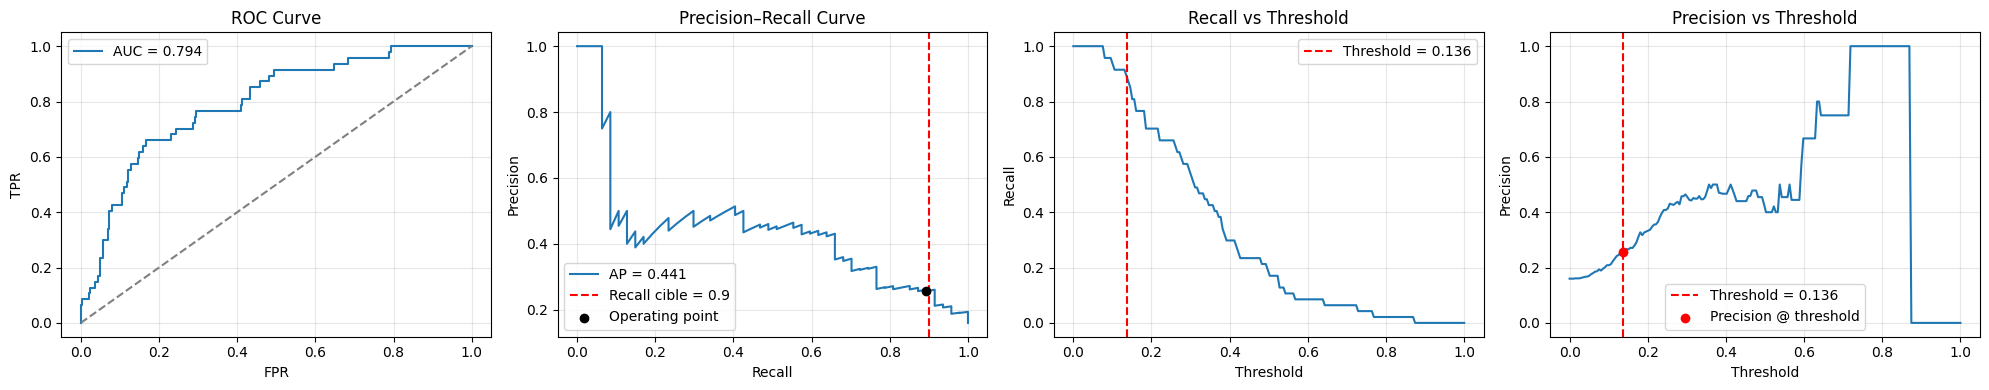

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix,
    recall_score, precision_score, f1_score,
    average_precision_score
)

# =========================
# 1) Probabilités prédictes
# =========================
y_proba = grid.predict_proba(X_test)[:, 1]

# =========================
# 2) Seuil pour recall cible
# =========================
target_recall = 0.90
thresholds = np.linspace(0, 1, 1000)

best_thr = 0
best_diff = np.inf

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    r = recall_score(y_test, y_pred_thr)
    diff = abs(r - target_recall)
    if diff < best_diff:
        best_diff = diff
        best_thr = thr

print(f"🎯 Seuil optimal pour recall ≈ {target_recall}: {best_thr:.4f}")

# Prédictions finales
y_pred_recall_target = (y_proba >= best_thr).astype(int)

print("\nRecall :", round(recall_score(y_test, y_pred_recall_target), 4))
print("Precision :", round(precision_score(y_test, y_pred_recall_target), 4))
print("F1 :", round(f1_score(y_test, y_pred_recall_target), 4))
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred_recall_target))

# =========================
# Préparation courbes seuils
# =========================
thresholds_plot = np.linspace(0, 1, 200)

recalls_plot = [
    recall_score(y_test, (y_proba >= t).astype(int))
    for t in thresholds_plot
]

precisions_plot = [
    precision_score(y_test, (y_proba >= t).astype(int), zero_division=0)
    for t in thresholds_plot
]

# =========================
# PLOTS
# =========================
plt.figure(figsize=(20, 4))

# 1️⃣ ROC
plt.subplot(1, 4, 1)
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(alpha=0.3)

# 2️⃣ Precision–Recall
plt.subplot(1, 4, 2)
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.plot(rec, prec, label=f"AP = {average_precision_score(y_test, y_proba):.3f}")
plt.axvline(target_recall, color="red", linestyle="--",
            label=f"Recall cible = {target_recall}")
plt.scatter(
    recall_score(y_test, y_pred_recall_target),
    precision_score(y_test, y_pred_recall_target),
    color="black",
    zorder=5,
    label="Operating point"
)
plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)

# 3️⃣ Recall vs Threshold
plt.subplot(1, 4, 3)
plt.plot(thresholds_plot, recalls_plot)
plt.axvline(best_thr, color="red", linestyle="--",
            label=f"Threshold = {best_thr:.3f}")
plt.title("Recall vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.grid(alpha=0.3)

# 4️⃣ Precision vs Threshold
plt.subplot(1, 4, 4)
plt.plot(thresholds_plot, precisions_plot)
plt.axvline(best_thr, color="red", linestyle="--",
            label=f"Threshold = {best_thr:.3f}")
plt.scatter(
    best_thr,
    precision_score(y_test, y_pred_recall_target),
    color="red",
    zorder=5,
    label="Precision @ threshold"
)
plt.title("Precision vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [18]:
print(df_model.shape)
df_model.isna().sum()
df_model.head()

(1470, 35)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,ratio_stagnation,satisfaction_globale,stress
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,...,1,2,Infra & Cloud,Y,Occasionnel,0,5,0.000000,2.00,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,...,8,1,Infra & Cloud,Y,Frequent,1,7,0.090909,3.00,0
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,...,2,2,Autre,Y,Occasionnel,0,0,0.000000,3.00,2
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,...,3,4,Infra & Cloud,Y,Frequent,3,0,0.333333,3.25,2
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,...,2,1,Transformation Digitale,Y,Occasionnel,2,2,0.666667,2.50,0


In [19]:
df_model["a_quitte_l_entreprise"].head(10)
df_model["a_quitte_l_entreprise"].isna().sum()
df_model["a_quitte_l_entreprise"].value_counts()

a_quitte_l_entreprise
0    1233
1     237
Name: count, dtype: int64


📌 Random Forest

🎯 Best threshold (F1) : 0.3094
AUC        : 0.8045
Recall     : 0.6383
Precision  : 0.4762
F1         : 0.5455

Matrice de confusion:
[[214  33]
 [ 17  30]]

Classification report:
              precision    recall  f1-score   support

           0     0.9264    0.8664    0.8954       247
           1     0.4762    0.6383    0.5455        47

    accuracy                         0.8299       294
   macro avg     0.7013    0.7523    0.7204       294
weighted avg     0.8544    0.8299    0.8395       294



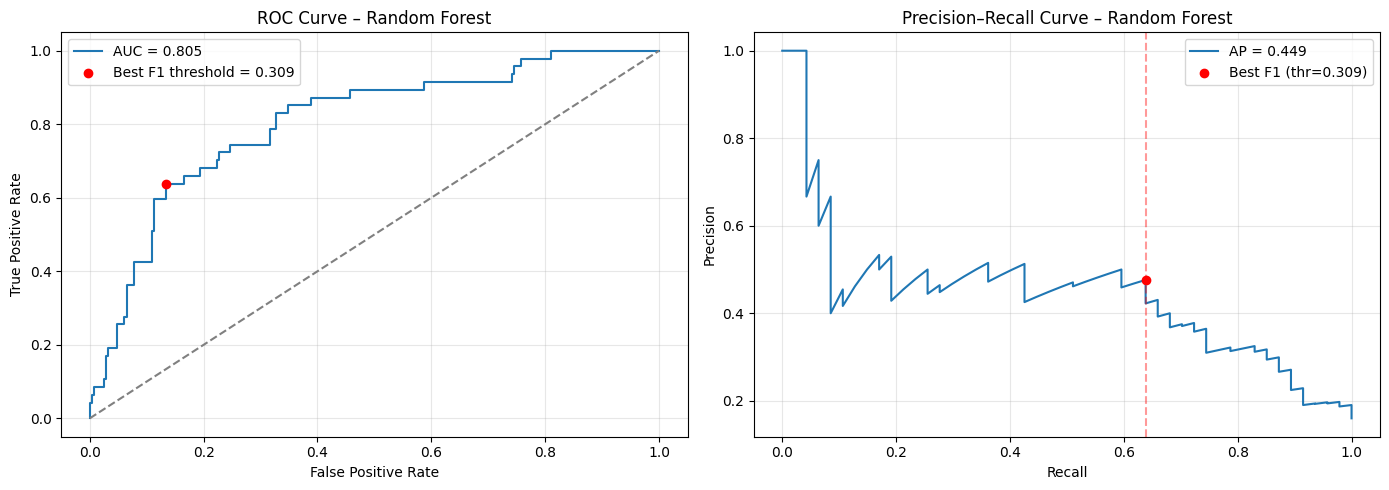


📌 XGBoost

🎯 Best threshold (F1) : 0.1494
AUC        : 0.7919
Recall     : 0.6383
Precision  : 0.4286
F1         : 0.5128

Matrice de confusion:
[[207  40]
 [ 17  30]]

Classification report:
              precision    recall  f1-score   support

           0     0.9241    0.8381    0.8790       247
           1     0.4286    0.6383    0.5128        47

    accuracy                         0.8061       294
   macro avg     0.6763    0.7382    0.6959       294
weighted avg     0.8449    0.8061    0.8204       294



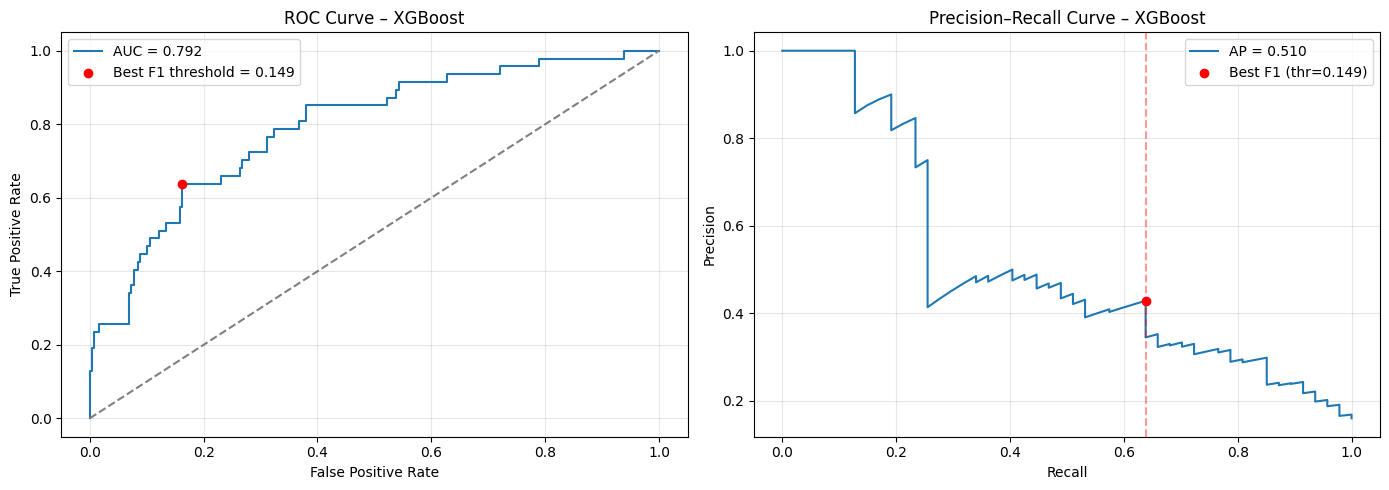

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000611 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 654
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632

📌 LightGBM

🎯 Best threshold (F1) : 0.0647
AUC        : 0.8045
Recall     : 0.6170
Precision  : 0.4265
F1         : 0.5043

Matrice de confusion:
[[208  39]
 [ 18  29]]

Classification report:
              precision    recall  f1-score   support

           0     0.9204    0.8421    0.8795       247
           1     0.4265    0.6170    0.5043        47

    accura

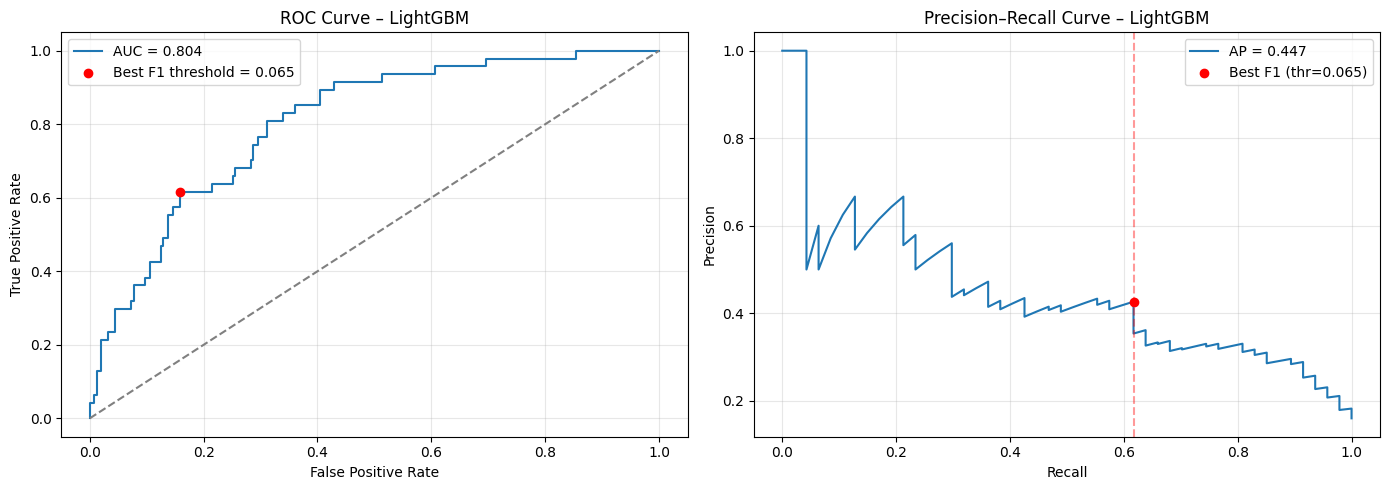

/Users/valerianbarreau/Documents/Op_Ai_engineer/valerian_mlops/Valerian_barreau_deployez_un_modèle de_Machine_Learning_1_03_2026/env_mlops_classifier/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/valerianbarreau/Documents/Op_Ai_engineer/valerian_mlops/Valerian_barreau_deployez_un_modèle de_Machine_Learning_1_03_2026/env_mlops_classifier/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200


📌 Logistic Regression (Calibrated)

🎯 Best threshold (F1) : 0.3798
AUC        : 0.8062
Recall     : 0.5106
Precision  : 0.6154
F1         : 0.5581

Matrice de confusion:
[[232  15]
 [ 23  24]]

Classification report:
              precision    recall  f1-score   support

           0     0.9098    0.9393    0.9243       247
           1     0.6154    0.5106    0.5581        47

    accuracy                         0.8707       294
   macro avg     0.7626    0.7250    0.7412       294
weighted avg     0.8627    0.8707    0.8658       294



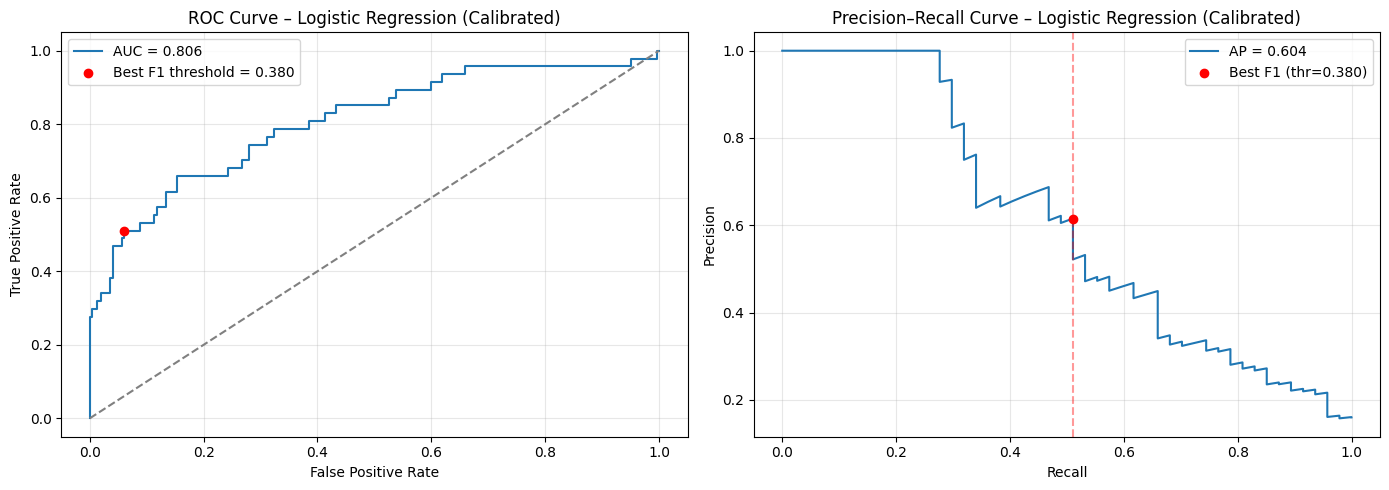


📊 COMPARAISON DES MODÈLES
                              Model       AUC    Recall  Precision        F1  \
0                     Random Forest  0.804548  0.638298   0.476190  0.545455   
1                           XGBoost  0.791886  0.638298   0.428571  0.512821   
2                          LightGBM  0.804462  0.617021   0.426471  0.504348   
3  Logistic Regression (Calibrated)  0.806185  0.510638   0.615385  0.558140   

   Threshold_F1  
0      0.309370  
1      0.149399  
2      0.064658  
3      0.379776  


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    recall_score, precision_score, f1_score,
    average_precision_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ==========================
# FONCTION D’ÉVALUATION UNIQUE
# ==========================
def evaluate_model(name, model, X_test, y_test):

    print(f"\n==========================")
    print(f"📌 {name}")
    print(f"==========================\n")

    # ==========================
    # Probabilités
    # ==========================
    y_proba = model.predict_proba(X_test)[:, 1]

    # ==========================
    # Best threshold basé sur F1
    # ==========================
    prec, rec, thr = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = np.argmax(f1_scores)

    best_thr = thr[best_idx]
    best_f1 = f1_scores[best_idx]

    # ==========================
    # Prédictions au seuil optimal
    # ==========================
    y_pred = (y_proba >= best_thr).astype(int)

    best_recall = recall_score(y_test, y_pred)
    best_precision = precision_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_proba)

    print(f"🎯 Best threshold (F1) : {best_thr:.4f}")
    print(f"AUC        : {auc:.4f}")
    print(f"Recall     : {best_recall:.4f}")
    print(f"Precision  : {best_precision:.4f}")
    print(f"F1         : {f1_score(y_test, y_pred):.4f}")

    print("\nMatrice de confusion:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))

    # ==========================
    # Courbes ROC & PR
    # ==========================
    fpr, tpr, roc_thr = roc_curve(y_test, y_proba)

    idx_roc = np.argmin(np.abs(roc_thr - best_thr))
    best_fpr = fpr[idx_roc]
    best_tpr = tpr[idx_roc]

    plt.figure(figsize=(14, 5))

    # ---- ROC
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.scatter(
        best_fpr, best_tpr,
        color="red", zorder=5,
        label=f"Best F1 threshold = {best_thr:.3f}"
    )
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.title(f"ROC Curve – {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(alpha=0.3)
    plt.legend()

    # ---- Precision–Recall
    plt.subplot(1, 2, 2)
    plt.plot(rec, prec, label=f"AP = {average_precision_score(y_test, y_proba):.3f}")
    plt.scatter(
        best_recall, best_precision,
        color="red", zorder=5,
        label=f"Best F1 (thr={best_thr:.3f})"
    )
    plt.axvline(best_recall, color="red", linestyle="--", alpha=0.4)
    plt.title(f"Precision–Recall Curve – {name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "AUC": auc,
        "Recall": best_recall,
        "Precision": best_precision,
        "F1": f1_score(y_test, y_pred),
        "Threshold_F1": best_thr
    }


# ==========================
# MODÈLES
# ==========================

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
res_rf = evaluate_model("Random Forest", rf, X_test, y_test)


xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
res_xgb = evaluate_model("XGBoost", xgb, X_test, y_test)


lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8
)
lgb.fit(X_train, y_train)
res_lgb = evaluate_model("LightGBM", lgb, X_test, y_test)


base_lr = LogisticRegressionCV(
    penalty="l2",
    solver="lbfgs",
    cv=5,
    max_iter=2000
)

calibrated_lr = CalibratedClassifierCV(base_lr, cv=5)
calibrated_lr.fit(X_train, y_train)
res_lr = evaluate_model("Logistic Regression (Calibrated)", calibrated_lr, X_test, y_test)


# ==========================
# TABLEAU COMPARATIF FINAL
# ==========================
df_results = pd.DataFrame([res_rf, res_xgb, res_lgb, res_lr])

print("\n==========================")
print("📊 COMPARAISON DES MODÈLES")
print("==========================")
print(df_results)


In [21]:
df.info()
# df.dropna(axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   id_employee                                1470 non-null   int64 
 1   age                                        1470 non-null   int64 
 2   genre                                      1470 non-null   object
 3   revenu_mensuel                             1470 non-null   int64 
 4   statut_marital                             1470 non-null   object
 5   departement                                1470 non-null   object
 6   poste                                      1470 non-null   object
 7   nombre_experiences_precedentes             1470 non-null   int64 
 8   nombre_heures_travailless                  1470 non-null   int64 
 9   annee_experience_totale                    1470 non-null   int64 
 10  annees_dans_l_entreprise            

In [22]:
def evaluate_model_best_recall(
    name,
    model,
    X_test,
    y_test,
    min_precision=0.25
):
    print(f"\n==========================")
    print(f"📌 {name} (Recall optimized | Precision ≥ {min_precision})")
    print(f"==========================\n")

    # =========================
    # Probabilités
    # =========================
    y_proba = model.predict_proba(X_test)[:, 1]

    # =========================
    # Courbe Precision–Recall
    # =========================
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    # thresholds a une taille -1 → on aligne
    thresholds = np.append(thresholds, 1.0)

    # =========================
    # Seuil max recall sous contrainte precision
    # =========================
    valid_idx = np.where(precision >= min_precision)[0]

    if len(valid_idx) == 0:
        print("⚠️ Aucun seuil ne respecte la précision minimale.")
        best_idx = int(np.argmax(recall))
    else:
        best_idx = int(valid_idx[np.argmax(recall[valid_idx])])

    best_thr = float(thresholds[best_idx])

    print(f"👉 Best threshold (Recall max, Precision ≥ {min_precision}) : {best_thr:.4f}")

    # =========================
    # Prédictions au seuil optimal
    # =========================
    y_pred = (y_proba >= best_thr).astype(int)

    # =========================
    # Scores
    # =========================
    auc = roc_auc_score(y_test, y_proba)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred)

    print(f"AUC        : {auc:.4f}")
    print(f"Recall     : {rec:.4f}")
    print(f"Precision  : {prec:.4f}")
    print(f"F1         : {f1:.4f}")

    # =========================
    # Matrice & rapport
    # =========================
    print("\nMatrice de confusion:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))

    # =========================
    # Courbes ROC & PR
    # =========================
    fpr, tpr, roc_thr = roc_curve(y_test, y_proba)

    # Point ROC correspondant au seuil choisi
    idx_roc = np.argmin(np.abs(roc_thr - best_thr))
    best_fpr = fpr[idx_roc]
    best_tpr = tpr[idx_roc]

    plt.figure(figsize=(14, 5))

    # ---- ROC
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.scatter(
        best_fpr,
        best_tpr,
        color="red",
        zorder=5,
        label=f"Operating point (thr={best_thr:.3f})"
    )
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.title(f"ROC – {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(alpha=0.3)
    plt.legend()

    # ---- Precision–Recall
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label="PR curve")
    plt.scatter(
        recall[best_idx],
        precision[best_idx],
        color="red",
        zorder=5,
        label="Best recall (precision constrained)"
    )
    plt.axhline(min_precision, color="gray", linestyle="--", alpha=0.5,
                label=f"Min precision = {min_precision}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall – {name}")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return {
        "model": name,
        "AUC": auc,
        "Recall": rec,
        "Precision": prec,
        "F1": f1,
        "Threshold_recall_opt": best_thr,
        "Min_precision_constraint": min_precision
    }


In [23]:
import numpy as np
from sklearn.metrics import make_scorer, precision_recall_curve, recall_score

def recall_at_min_precision(y_true, y_proba, min_precision=0.25):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    thresholds = np.append(thresholds, 1.0)
    valid_idx = np.where(precision >= min_precision)[0]
    if len(valid_idx) == 0:
        return 0.0
    best_idx = int(valid_idx[np.argmax(recall[valid_idx])])
    y_pred = (y_proba >= thresholds[best_idx]).astype(int)
    return recall_score(y_true, y_pred)

custom_scorer = make_scorer(
    recall_at_min_precision,
    response_method="predict_proba",  # ← remplace needs_proba=True
    min_precision=0.25
)
print("✅ custom_scorer prêt")

✅ custom_scorer prêt


Fitting 5 folds for each of 24 candidates, totalling 120 fits
✅ RF — Meilleurs params : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
   Meilleur recall CV   : 0.8684

📌 Random Forest (GridSearch) (Recall optimized | Precision ≥ 0.25)

👉 Best threshold (Recall max, Precision ≥ 0.25) : 0.1287
AUC        : 0.7937
Recall     : 0.9149
Precision  : 0.2500
F1         : 0.3927

Matrice de confusion:
[[118 129]
 [  4  43]]

Classification report:
              precision    recall  f1-score   support

           0     0.9672    0.4777    0.6396       247
           1     0.2500    0.9149    0.3927        47

    accuracy                         0.5476       294
   macro avg     0.6086    0.6963    0.5161       294
weighted avg     0.8526    0.5476    0.6001       294



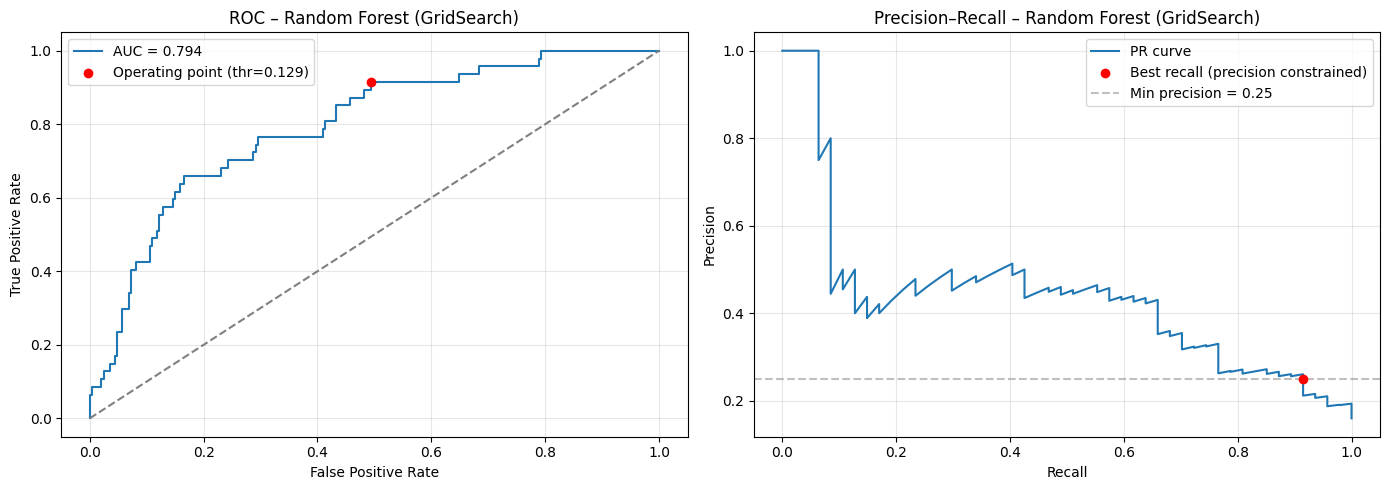

In [24]:
# ─── AVANT (à supprimer) ───────────────────────────
# rf.fit(X_train, y_train)          ← inutile, double travail
# results_rf = evaluate_model_best_recall(...)  ← sur l'ancien rf non optimisé

# ─── APRÈS ─────────────────────────────────────────
rf_params = {
    "n_estimators": [300, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=rf_params,
    scoring=custom_scorer,  # recall max avec precision >= 0.25
    cv=5,
    n_jobs=-1,
    verbose=1,
    refit=True
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_  # ← modèle optimisé, déjà refitté

print("✅ RF — Meilleurs params :", grid_rf.best_params_)
print("   Meilleur recall CV   :", round(grid_rf.best_score_, 4))

# Évaluation sur le test set
results_rf = evaluate_model_best_recall(
    "Random Forest (GridSearch)",
    best_rf,           # ← utilise best_rf, pas rf
    X_test,
    y_test,
    min_precision=0.25
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
✅ XGB — Meilleurs params : {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400, 'scale_pos_weight': 5, 'subsample': 0.8}
   Meilleur recall CV   : 0.8737

📌 XGBoost (GridSearch) (Recall optimized | Precision ≥ 0.25)

👉 Best threshold (Recall max, Precision ≥ 0.25) : 0.0056
AUC        : 0.7988
Recall     : 0.8936
Precision  : 0.2500
F1         : 0.3907

Matrice de confusion:
[[121 126]
 [  5  42]]

Classification report:
              precision    recall  f1-score   support

           0     0.9603    0.4899    0.6488       247
           1     0.2500    0.8936    0.3907        47

    accuracy                         0.5544       294
   macro avg     0.6052    0.6917    0.5197       294
weighted avg     0.8468    0.5544    0.6075       294



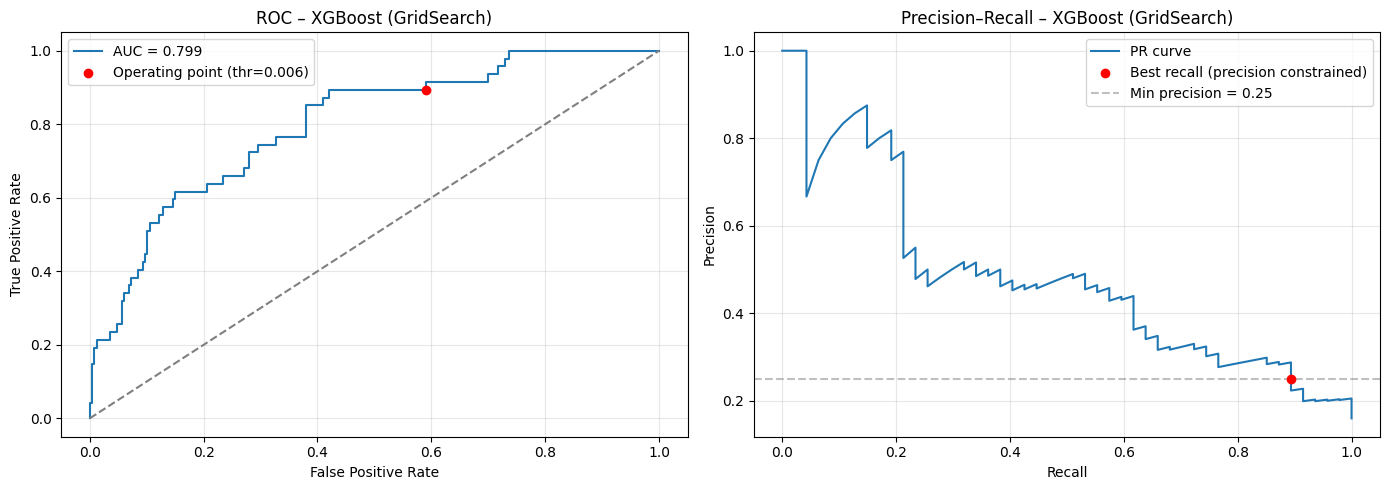

In [25]:
# GridSearch XGBoost — optimisé recall avec precision >= 0.25
xgb_params = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "scale_pos_weight": [3, 5],
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid=xgb_params,
    scoring=custom_scorer,   # ← décommenté !
    cv=5,
    n_jobs=-1,
    verbose=1,
    refit=True
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

print("✅ XGB — Meilleurs params :", grid_xgb.best_params_)
print("   Meilleur recall CV   :", round(grid_xgb.best_score_, 4))

# Évaluation sur le test set avec le meilleur modèle
results_xgb = evaluate_model_best_recall(
    "XGBoost (GridSearch)",
    best_xgb,        # ← best_xgb, pas xgb
    X_test,
    y_test,
    min_precision=0.25
)


📌 LightGBM (Recall optimized | Precision ≥ 0.25)

👉 Best threshold (Recall max, Precision ≥ 0.25) : 0.0017
AUC        : 0.8045
Recall     : 0.9362
Precision  : 0.2500
F1         : 0.3946

Matrice de confusion:
[[115 132]
 [  3  44]]

Classification report:
              precision    recall  f1-score   support

           0     0.9746    0.4656    0.6301       247
           1     0.2500    0.9362    0.3946        47

    accuracy                         0.5408       294
   macro avg     0.6123    0.7009    0.5124       294
weighted avg     0.8587    0.5408    0.5925       294



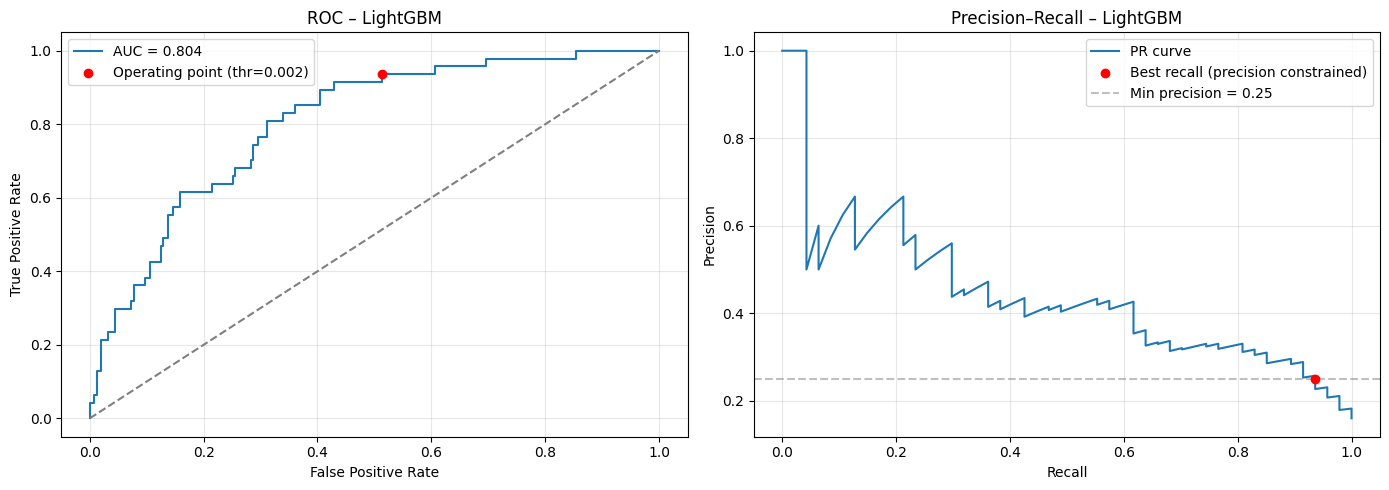

Fitting 5 folds for each of 2 candidates, totalling 10 fits
✅ LGB — Meilleurs params : {'is_unbalance': True, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 31}
   Meilleur recall CV   : 0.8631


In [26]:
# lgb.fit(X_train, y_train)
results_lgb = evaluate_model_best_recall(
    "LightGBM",
    lgb,
    X_test,
    y_test,
    min_precision=0.25
)
lgb_params = {
    "n_estimators": [200],          # au lieu de [200, 400]
    "max_depth": [6, 10],           # au lieu de [6, 10, -1]
    "learning_rate": [0.1],         # au lieu de [0.05, 0.1]
    "num_leaves": [31],             # au lieu de [31, 63]
    "is_unbalance": [True],
}       # équivalent class_weight="balanced"


grid_lgb = GridSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_grid=lgb_params,
    # scoring=custom_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1,
    refit=True
)
grid_lgb.fit(X_train, y_train)
best_lgb = grid_lgb.best_estimator_

print("✅ LGB — Meilleurs params :", grid_lgb.best_params_)
print("   Meilleur recall CV   :", round(grid_lgb.best_score_, 4))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
✅ LR — Meilleurs params : {'estimator__C': 0.01, 'estimator__class_weight': 'balanced', 'estimator__max_iter': 10000, 'estimator__solver': 'saga'}
   Meilleur recall CV   : 0.7215

📌 Logistic Regression (GridSearch) (Recall optimized | Precision ≥ 0.25)

👉 Best threshold (Recall max, Precision ≥ 0.25) : 0.2077
AUC        : 0.6477
Recall     : 0.4894
Precision  : 0.2500
F1         : 0.3309

Matrice de confusion:
[[178  69]
 [ 24  23]]

Classification report:
              precision    recall  f1-score   support

           0     0.8812    0.7206    0.7929       247
           1     0.2500    0.4894    0.3309        47

    accuracy                         0.6837       294
   macro avg     0.5656    0.6050    0.5619       294
weighted avg     0.7803    0.6837    0.7190       294



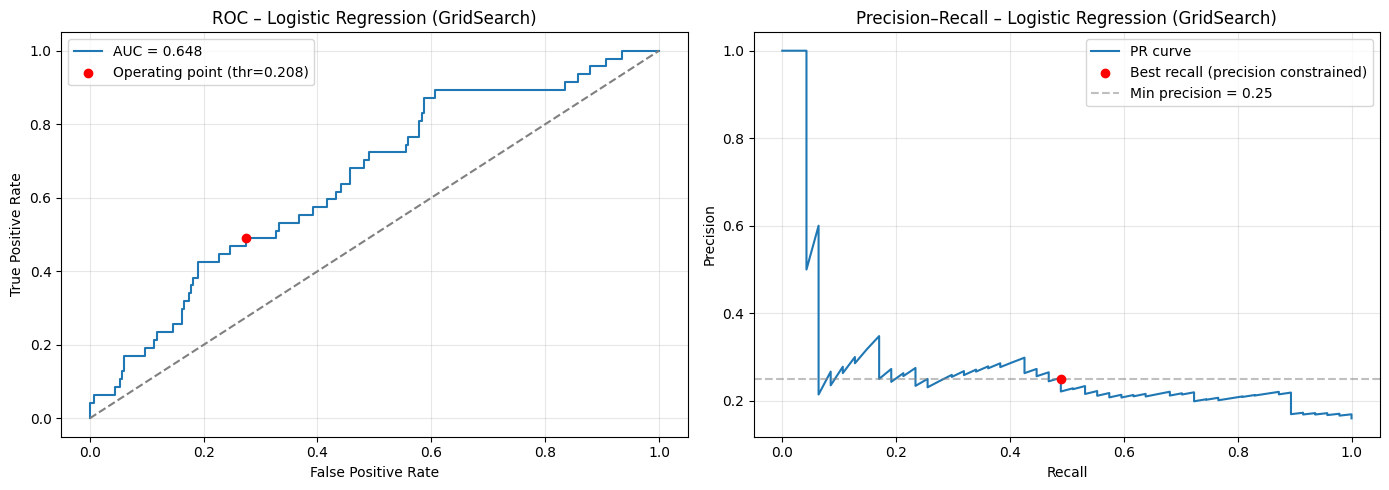

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

lr_params = {
    "estimator__C": [0.01, 0.1, 1.0, 10.0],   # régularisation
    "estimator__solver": ["saga"],
    "estimator__max_iter": [10000],
    "estimator__class_weight": ["balanced"],
}

grid_lr = GridSearchCV(
    CalibratedClassifierCV(
        LogisticRegression(random_state=42)
    ),
    param_grid=lr_params,
    scoring=custom_scorer,
    cv=3,
    n_jobs=-1,
    verbose=1,
    refit=True
)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_

print("✅ LR — Meilleurs params :", grid_lr.best_params_)
print("   Meilleur recall CV   :", round(grid_lr.best_score_, 4))

# Évaluation sur le test set
results_logreg = evaluate_model_best_recall(
    "Logistic Regression (GridSearch)",
    best_lr,        # ← best_lr, pas calibrated_lr
    X_test,
    y_test,
    min_precision=0.25
)


In [28]:
df_results = pd.DataFrame([
    results_xgb,
    results_lgb,
    results_logreg,
    results_rf
])

print("\n==========================")
print("📊 COMPARAISON – Recall optimisé")
print("==========================")
print(df_results.sort_values("Recall", ascending=False))



📊 COMPARAISON – Recall optimisé
                              model       AUC    Recall  Precision        F1  \
1                          LightGBM  0.804462  0.936170       0.25  0.394619   
3        Random Forest (GridSearch)  0.793695  0.914894       0.25  0.392694   
0              XGBoost (GridSearch)  0.798777  0.893617       0.25  0.390698   
2  Logistic Regression (GridSearch)  0.647687  0.489362       0.25  0.330935   

   Threshold_recall_opt  Min_precision_constraint  
1              0.001742                      0.25  
3              0.128695                      0.25  
0              0.005571                      0.25  
2              0.207680                      0.25  


In [29]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

# =====================================================
# LISTE DES MODÈLES (déjà entraînés)
# =====================================================
models = [
    ("XGBoost", xgb),
    ("LightGBM", lgb),
    ("Logistic (Calibrated)", calibrated_lr),
    ("RandomForest", best_model),
]

# =====================================================
# FONCTION D’ÉVALUATION UNIFIÉE
# =====================================================
def unified_evaluation(
    models,
    X_test,
    y_test,
    *,
    min_precision=0.25,
    default_threshold=0.5,
    round_digits=4,
):
    rows = []

    def _metrics_at_threshold(y_proba, thr):
        y_pred = (y_proba >= thr).astype(int)
        return (
            precision_score(y_test, y_pred, zero_division=0),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred),
        )

    def _r(x):
        if round_digits is None:
            return float(x)
        return round(float(x), round_digits)

    for name, model in models:
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)

        # -----------------------------
        # 1) Seuil par défaut (0.5)
        # -----------------------------
        p_def, r_def, f1_def = _metrics_at_threshold(
            y_proba, default_threshold
        )

        # -----------------------------
        # 2) Seuil optimal F1
        # -----------------------------
        prec, rec, thr = precision_recall_curve(y_test, y_proba)

        if len(thr) > 0:
            f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
            idx_f1 = int(np.argmax(f1s))
            thr_f1 = float(thr[idx_f1])
        else:
            thr_f1 = float(default_threshold)

        p_f1, r_f1, f1_f1 = _metrics_at_threshold(y_proba, thr_f1)

        # -----------------------------
        # 3) Seuil recall-opt (precision >= min_precision)
        # -----------------------------
        thr_ext = np.append(thr, 1.0)
        valid_idx = np.where(prec[:-1] >= min_precision)[0]

        if len(valid_idx) == 0:
            best_idx = int(np.argmax(rec[:-1]))
        else:
            best_idx = int(valid_idx[np.argmax(rec[:-1][valid_idx])])

        thr_rec = float(thr_ext[best_idx])
        p_rec, r_rec, f1_rec = _metrics_at_threshold(y_proba, thr_rec)

        rows.append(
            {
                "model": name,
                "AUC": _r(auc),

                "thr_default": _r(default_threshold),
                "prec_default": _r(p_def),
                "rec_default": _r(r_def),
                "f1_default": _r(f1_def),

                "thr_f1": _r(thr_f1),
                "prec_f1": _r(p_f1),
                "rec_f1": _r(r_f1),
                "f1_f1": _r(f1_f1),

                "thr_rec_opt": _r(thr_rec),
                "prec_rec_opt": _r(p_rec),
                "rec_rec_opt": _r(r_rec),
                "f1_rec_opt": _r(f1_rec),
            }
        )

    return pd.DataFrame(rows).set_index("model")


# =====================================================
# EXÉCUTION
# =====================================================
pd.set_option("display.max_columns", None)

df = unified_evaluation(
    models,
    X_test,
    y_test,
    min_precision=0.25,
    default_threshold=0.5,
    round_digits=4,
)

# =====================================================
# AFFICHAGE PRO (Styler SANS ERREUR)
# =====================================================
num_cols = df.select_dtypes(include="number").columns

df.style \
  .background_gradient(cmap="Blues", subset=num_cols) \
  .format({c: "{:.3f}" for c in num_cols}) \
  .set_caption(
      "Comparaison des modèles – seuil par défaut, F1-optimal et Recall-opt (precision ≥ 0.25)"
  )


,AUC,thr_default,prec_default,rec_default,f1_default,thr_f1,prec_f1,rec_f1,f1_f1,thr_rec_opt,prec_rec_opt,rec_rec_opt,f1_rec_opt
model,,,,,,,,,,,,,
XGBoost,0.792,0.500,0.632,0.255,0.364,0.149,0.429,0.638,0.513,0.037,0.250,0.851,0.387
LightGBM,0.804,0.500,0.560,0.298,0.389,0.065,0.426,0.617,0.504,0.002,0.250,0.936,0.395
Logistic (Calibrated),0.806,0.500,0.833,0.319,0.462,0.380,0.615,0.511,0.558,0.077,0.250,0.851,0.387
RandomForest,0.794,0.500,0.429,0.192,0.265,0.259,0.431,0.660,0.521,0.129,0.250,0.915,0.393


In [30]:
df = unified_evaluation(models, X_test, y_test)
df.columns

Index(['AUC', 'thr_default', 'prec_default', 'rec_default', 'f1_default',
       'thr_f1', 'prec_f1', 'rec_f1', 'f1_f1', 'thr_rec_opt', 'prec_rec_opt',
       'rec_rec_opt', 'f1_rec_opt'],
      dtype='object')


🔍 ANALYSE SHAP — XGBoost

📊 1. SUMMARY PLOT (Impact global)


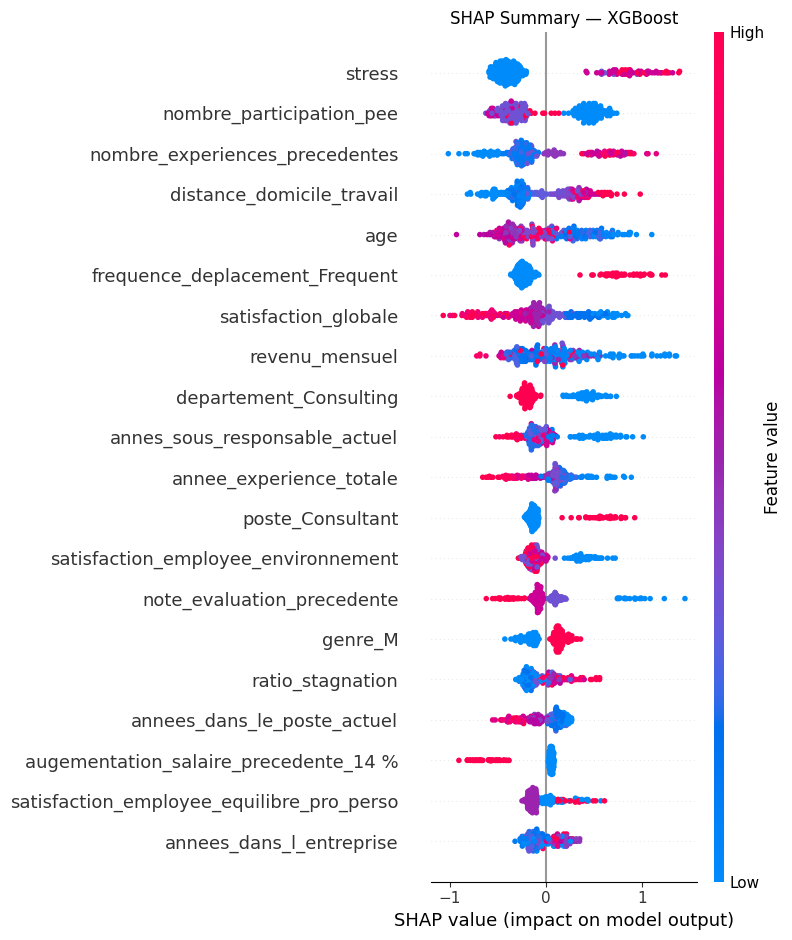

📊 2. BAR PLOT (Importance moyenne)


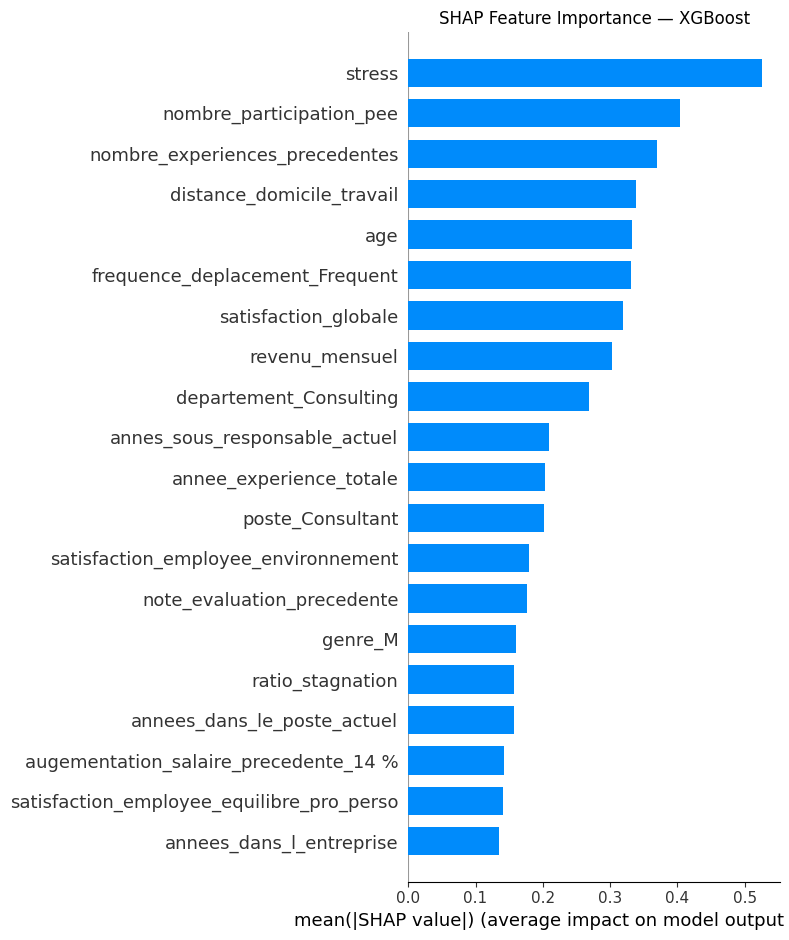

📊 3. DEPENDENCE PLOTS (Top 4 features)


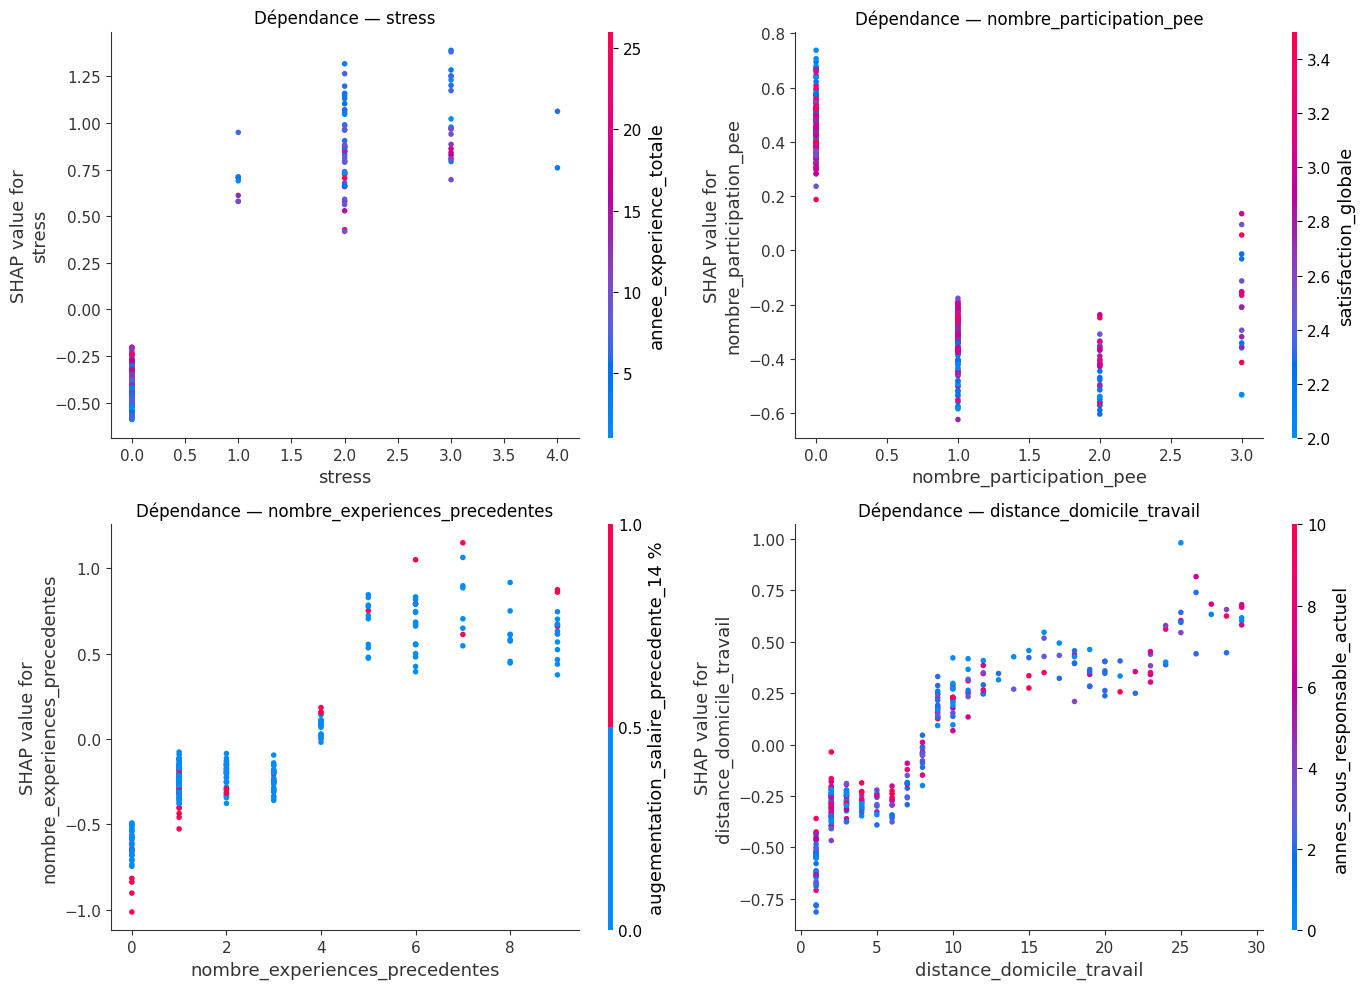

📊 4. FORCE PLOTS (Exemples locaux)


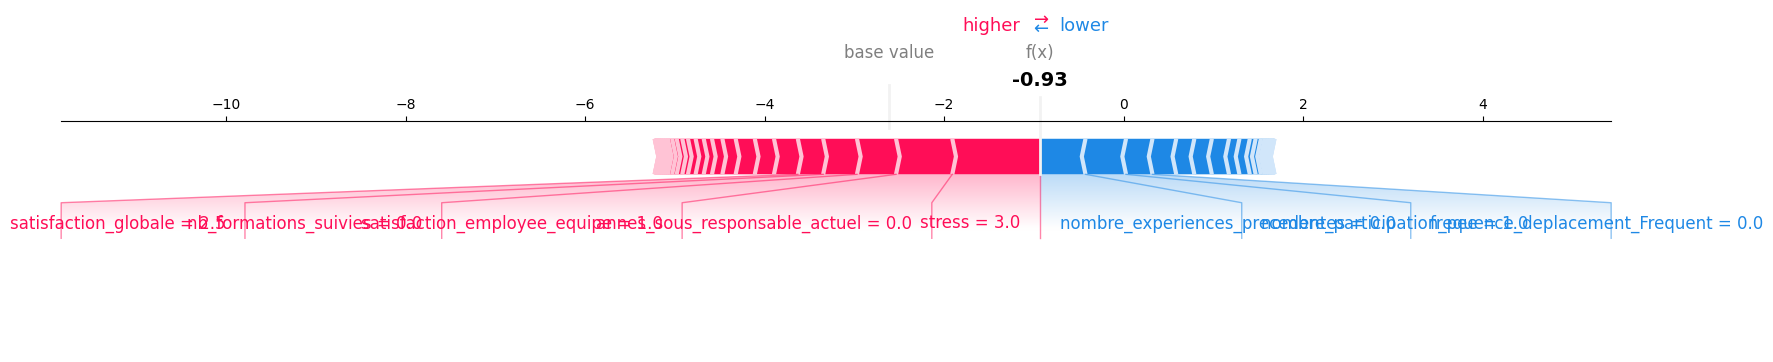

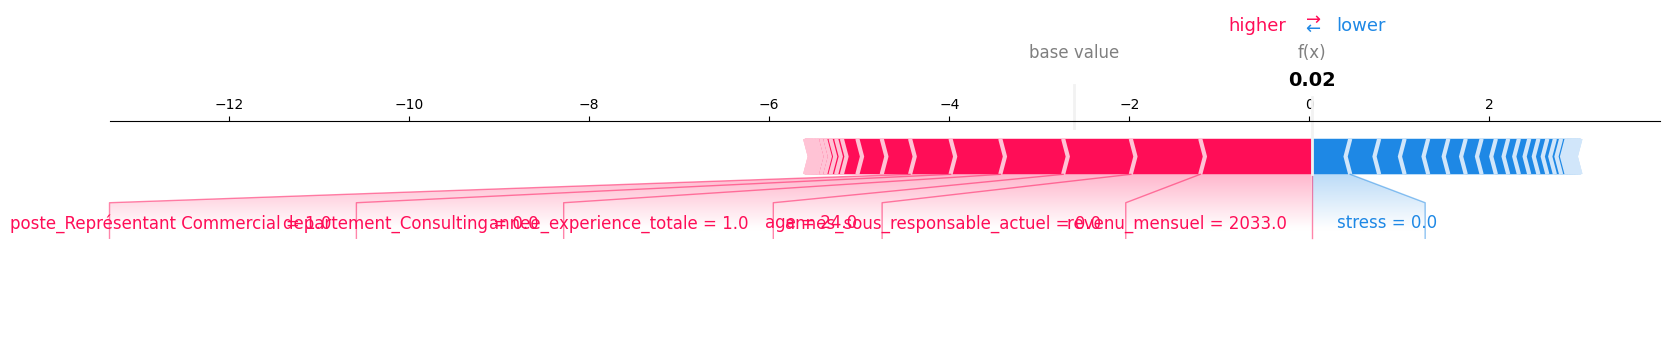

📊 5. RÉSUMÉ SHAP (Top 15 variables)
                                Feature  Mean |SHAP|
23                               stress     0.526276
14             nombre_participation_pee     0.403291
2        nombre_experiences_precedentes     0.370151
17            distance_domicile_travail     0.338559
0                                   age     0.333284
57       frequence_deplacement_Frequent     0.331642
22                 satisfaction_globale     0.319704
1                        revenu_mensuel     0.302998
27               departement_Consulting     0.269374
20        annes_sous_responsable_actuel     0.208673
4               annee_experience_totale     0.203421
30                     poste_Consultant     0.202093
7   satisfaction_employee_environnement     0.180095
8            note_evaluation_precedente     0.175948
24                              genre_M     0.159656

🔍 ANALYSE SHAP — LightGBM

📊 1. SUMMARY PLOT (Impact global)


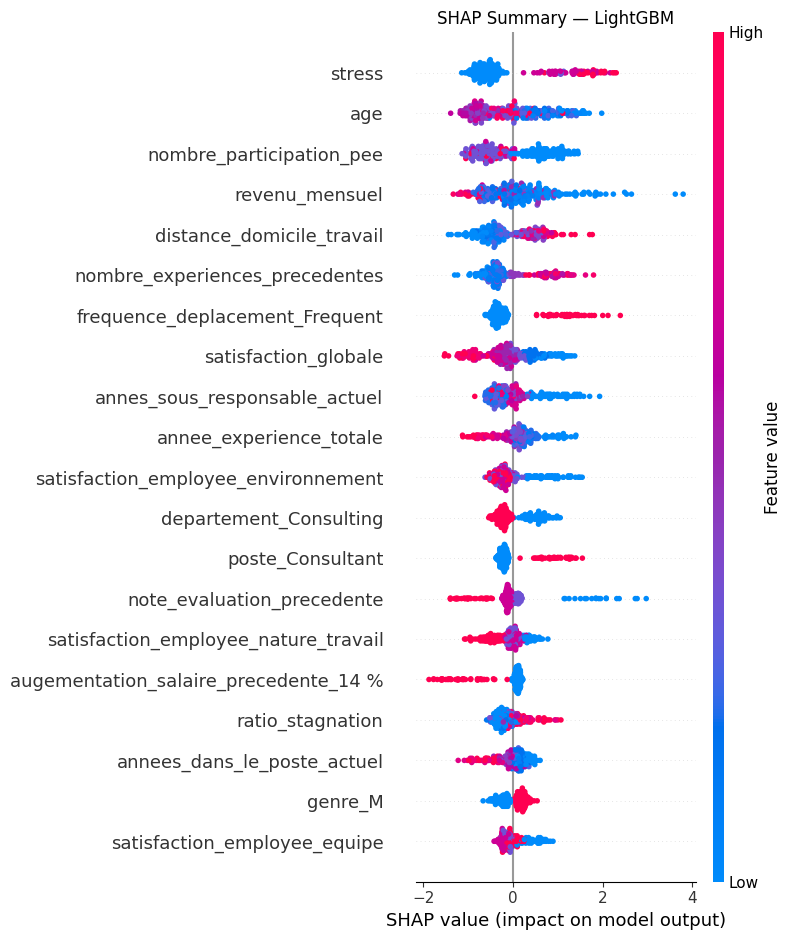

📊 2. BAR PLOT (Importance moyenne)


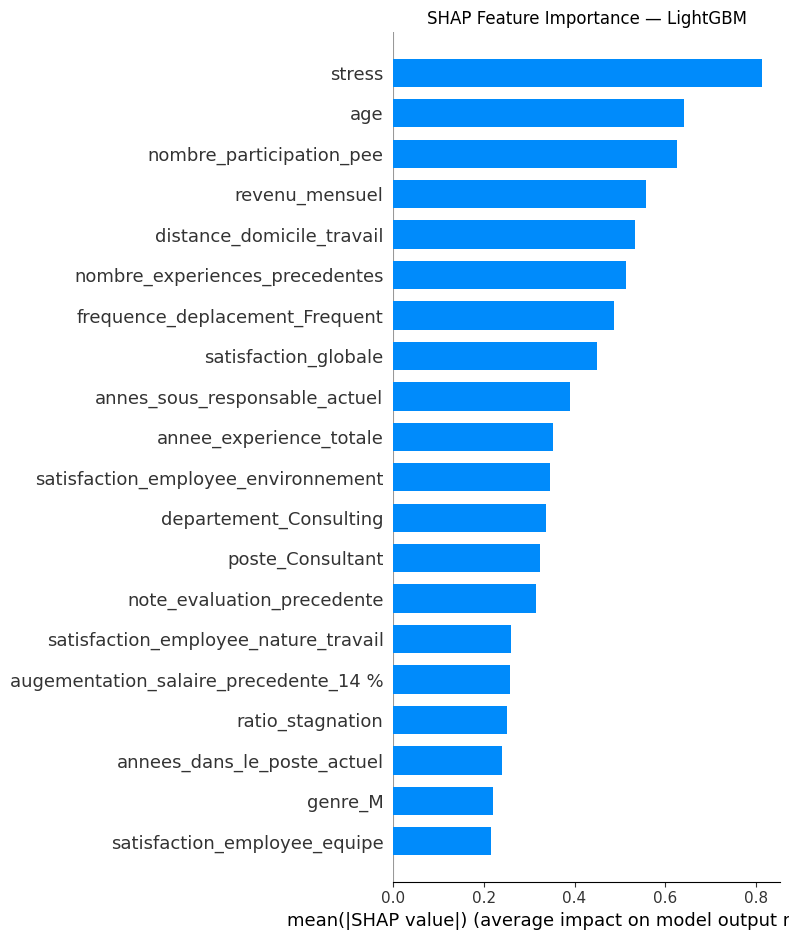

📊 3. DEPENDENCE PLOTS (Top 4 features)


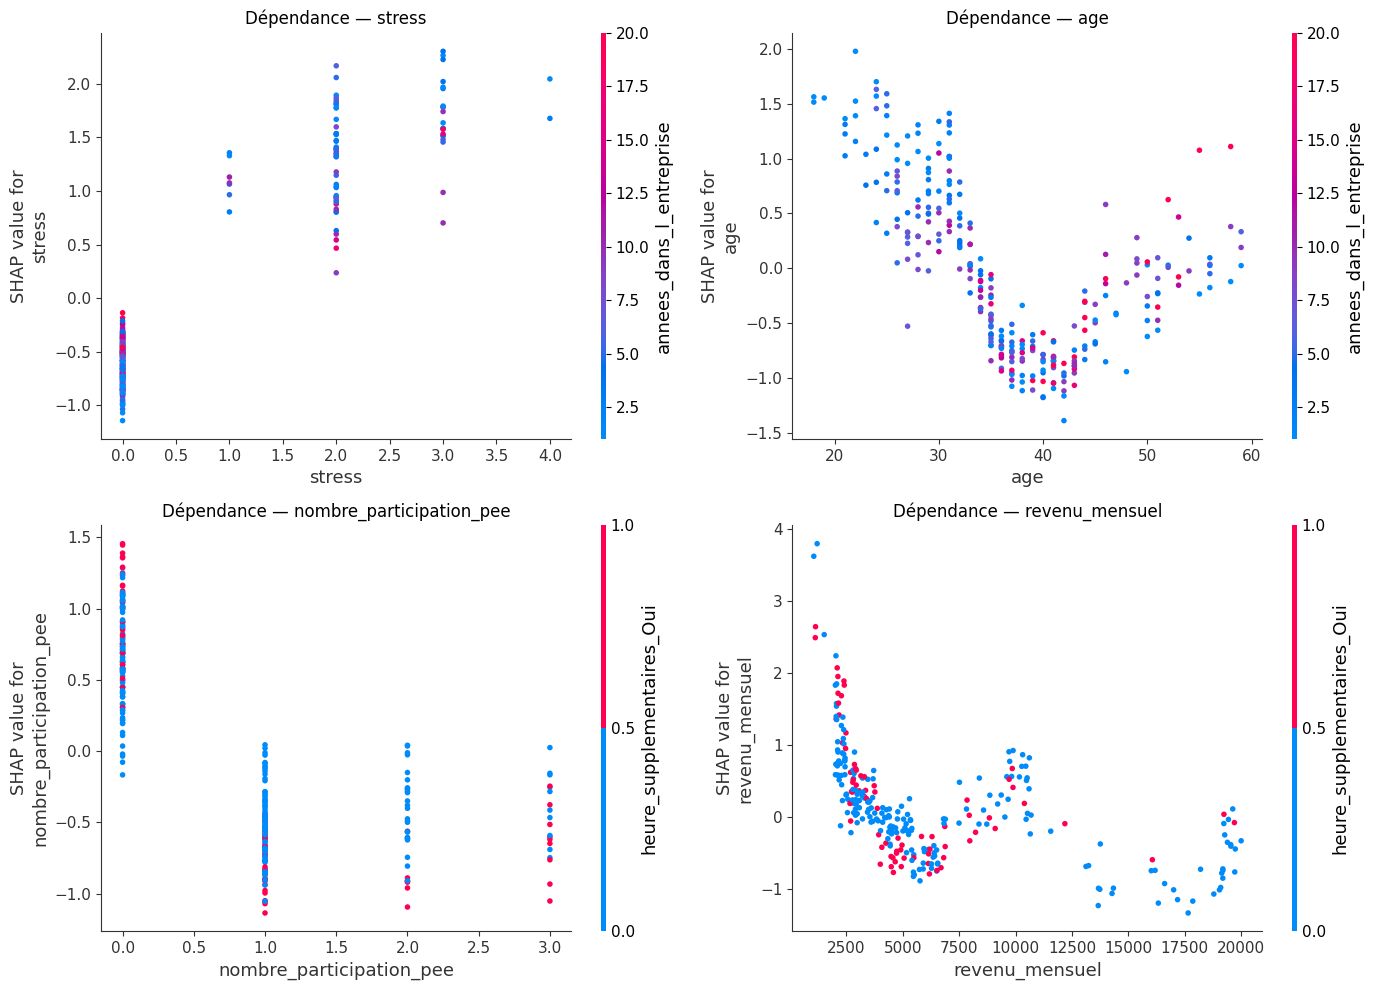

📊 4. FORCE PLOTS (Exemples locaux)


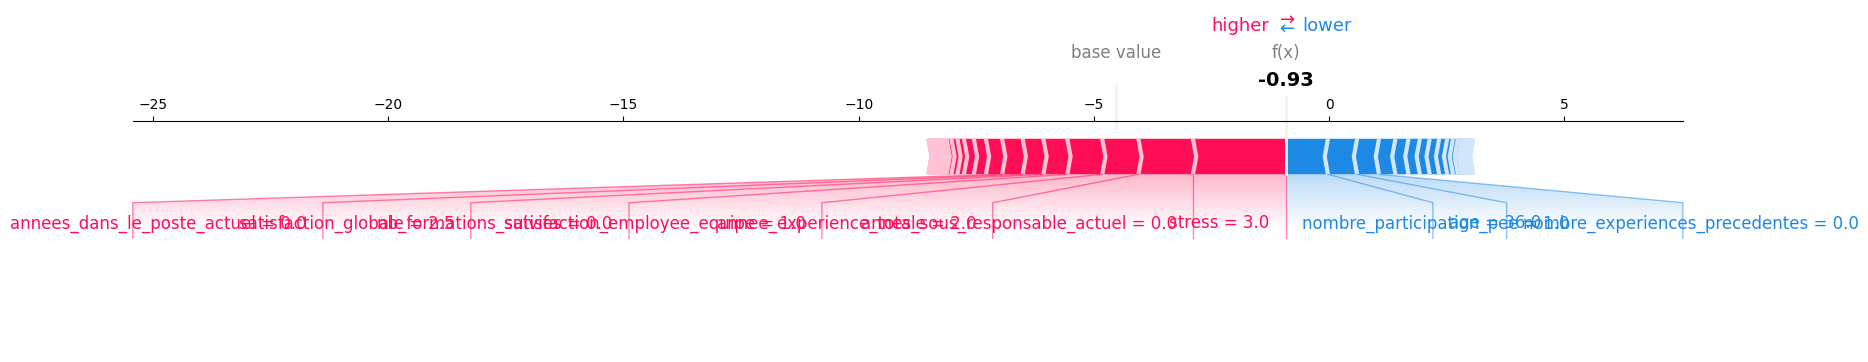

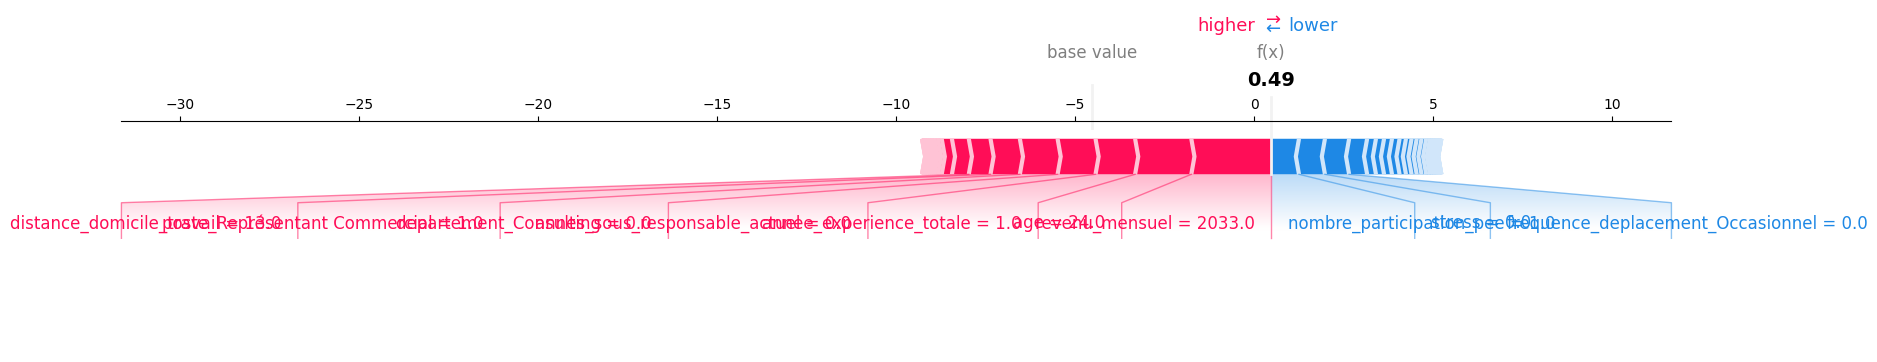

📊 5. RÉSUMÉ SHAP (Top 15 variables)
                                 Feature  Mean |SHAP|
23                                stress     0.812974
0                                    age     0.640978
14              nombre_participation_pee     0.625626
1                         revenu_mensuel     0.556687
17             distance_domicile_travail     0.533595
2         nombre_experiences_precedentes     0.513101
57        frequence_deplacement_Frequent     0.486645
22                  satisfaction_globale     0.449885
20         annes_sous_responsable_actuel     0.390125
4                annee_experience_totale     0.353241
7    satisfaction_employee_environnement     0.345111
27                departement_Consulting     0.337757
30                      poste_Consultant     0.324164
8             note_evaluation_precedente     0.314789
10  satisfaction_employee_nature_travail     0.260171

🔍 ANALYSE SHAP — Random Forest



 98%|===================| 579/588 [00:13<00:00]        

📊 1. SUMMARY PLOT (Impact global)


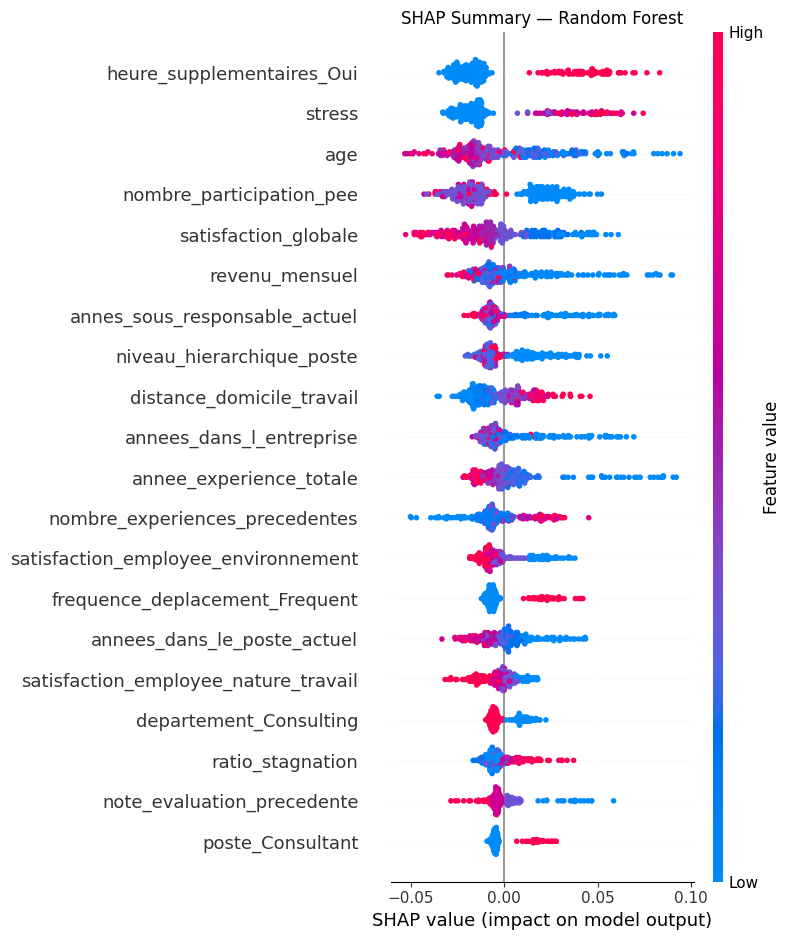

📊 2. BAR PLOT (Importance moyenne)


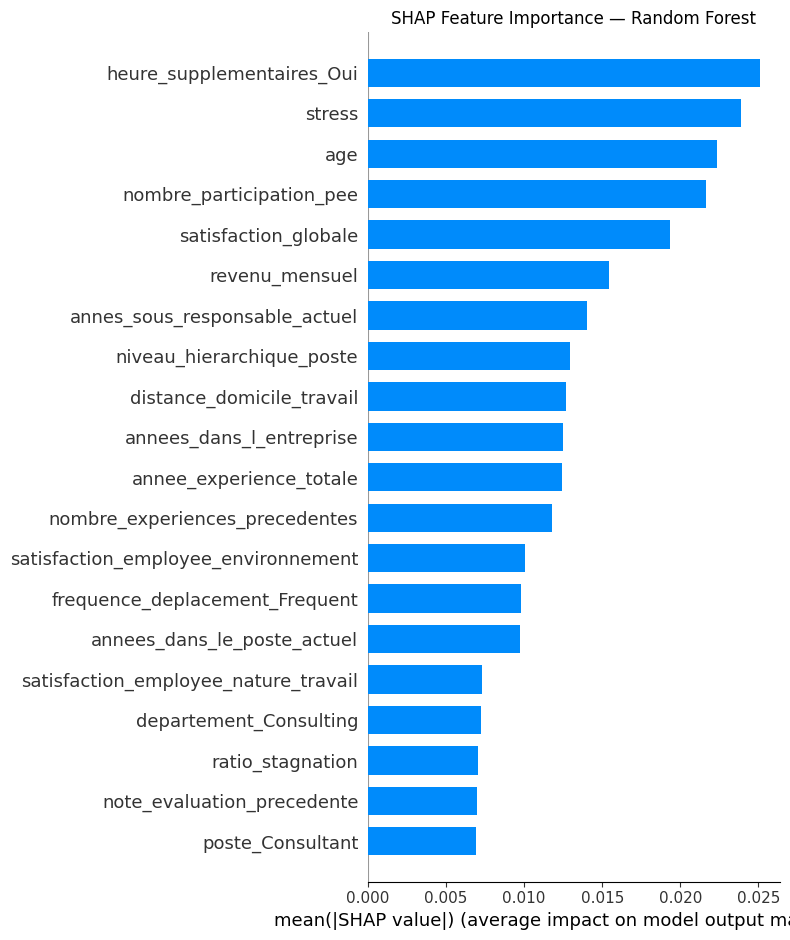

📊 3. DEPENDENCE PLOTS (Top 4 features)


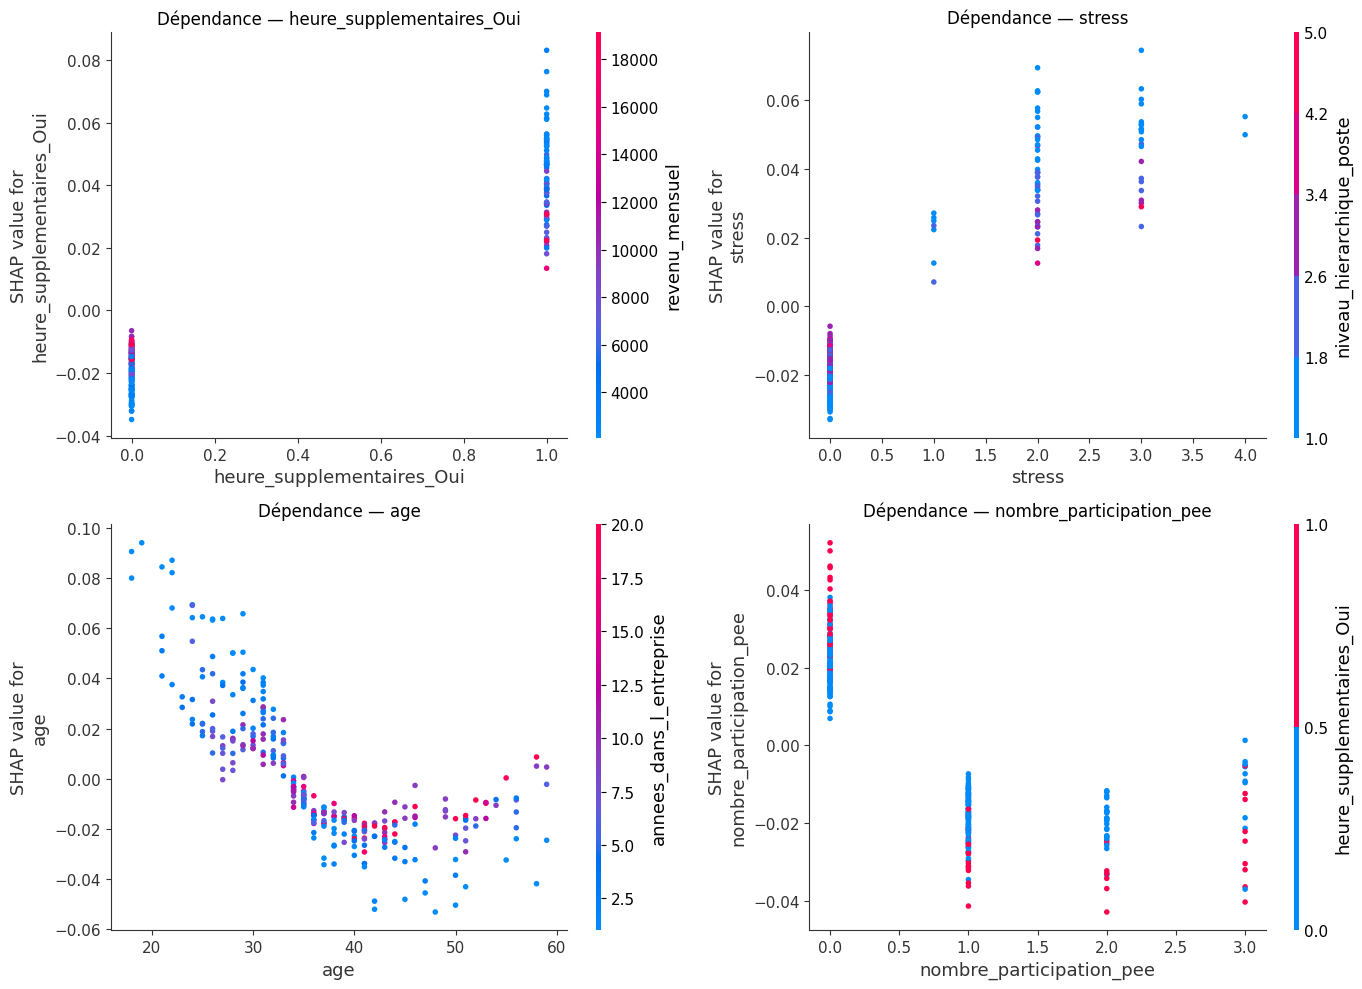

📊 4. FORCE PLOTS (Exemples locaux)


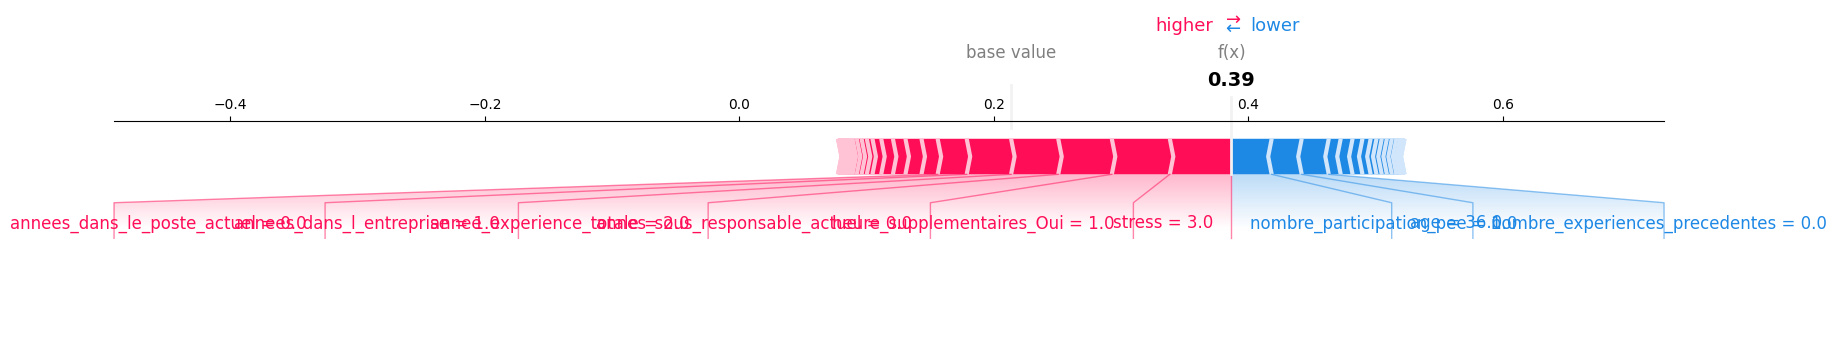

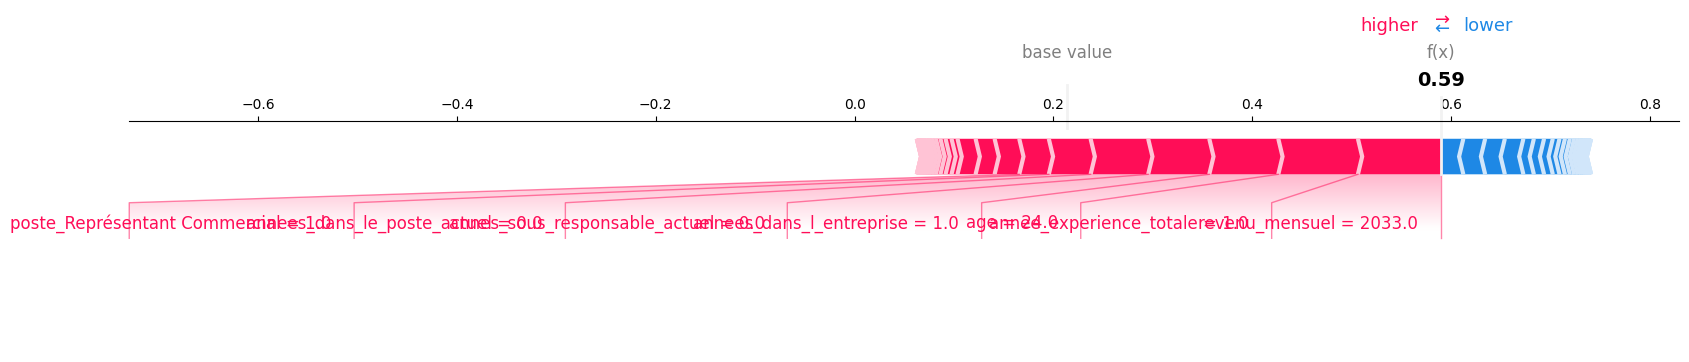

📊 5. RÉSUMÉ SHAP (Top 15 variables)
                                Feature  Mean |SHAP|
37            heure_supplementaires_Oui     0.025125
23                               stress     0.023904
0                                   age     0.022366
14             nombre_participation_pee     0.021631
22                 satisfaction_globale     0.019335
1                        revenu_mensuel     0.015417
20        annes_sous_responsable_actuel     0.014001
9             niveau_hierarchique_poste     0.012904
17            distance_domicile_travail     0.012649
5              annees_dans_l_entreprise     0.012465
4               annee_experience_totale     0.012432
2        nombre_experiences_precedentes     0.011793
7   satisfaction_employee_environnement     0.010040
57       frequence_deplacement_Frequent     0.009788
6           annees_dans_le_poste_actuel     0.009701


In [31]:
# =====================================================
# SHAP — ANALYSE COMPLÈTE TOUS LES MODÈLES (STABLE)
# Compatible SHAP >= 0.20
# =====================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 0. DONNÉES SHAP (NUMÉRIQUES, SÛRES)
# =====================================================
X_train_shap = (
    X_train
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(float)
)

X_test_shap = (
    X_test
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(float)
)

assert X_train_shap.shape[1] == X_test_shap.shape[1]

# =====================================================
# 1. MODÈLES À ANALYSER
# =====================================================
models_shap = [
    ("XGBoost", xgb),
    ("LightGBM", lgb),
    ("Random Forest", best_model),
    # ("Logistic (Calibrated)", calibrated_logreg)
]

# =====================================================
# 2. BOUCLE SHAP
# =====================================================
for model_name, model in models_shap:

    print("\n" + "=" * 70)
    print(f"🔍 ANALYSE SHAP — {model_name}")
    print("=" * 70 + "\n")

    # =================================================
    # 2.1 GESTION DU CAS LOGISTIC CALIBRÉE
    # =================================================
    if isinstance(model, type(calibrated_lr)):
        model_to_explain = model.estimator_  # modèle de base
        print("ℹ️ SHAP appliqué au modèle sous-jacent (logistic)")
    else:
        model_to_explain = model

    # =================================================
    # 2.2 EXPLAINER + SHAP VALUES
    # =================================================
    explainer = shap.Explainer(model_to_explain, X_train_shap)
    shap_values = explainer(X_test_shap)

    # =================================================
    # 2.3 EXTRACTION SHAP POUR CLASSE POSITIVE
    # =================================================
    if shap_values.values.ndim == 3:
        shap_vals_class1 = shap_values.values[:, :, 1]
    else:
        shap_vals_class1 = shap_values.values

    # Base value (classe positive)
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        base_value = expected_value[1]
    else:
        base_value = expected_value

    # =================================================
    # 3. SUMMARY PLOT
    # =================================================
    print("📊 1. SUMMARY PLOT (Impact global)")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals_class1, X_test_shap, show=False)
    plt.title(f"SHAP Summary — {model_name}")
    plt.tight_layout()
    plt.show()

    # =================================================
    # 4. BAR PLOT
    # =================================================
    print("📊 2. BAR PLOT (Importance moyenne)")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_vals_class1,
        X_test_shap,
        plot_type="bar",
        show=False
    )
    plt.title(f"SHAP Feature Importance — {model_name}")
    plt.tight_layout()
    plt.show()

    # =================================================
    # 5. DEPENDENCE PLOTS (TOP 4 FEATURES)
    # =================================================
    print("📊 3. DEPENDENCE PLOTS (Top 4 features)")
    shap_mean = np.abs(shap_vals_class1).mean(axis=0)
    top_indices = np.argsort(shap_mean)[-4:][::-1]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for idx, feature_idx in enumerate(top_indices):
        shap.dependence_plot(
            feature_idx,
            shap_vals_class1,
            X_test_shap.values,
            feature_names=X_test_shap.columns,
            ax=axes[idx],
            show=False
        )
        axes[idx].set_title(f"Dépendance — {X_test_shap.columns[feature_idx]}")

    plt.tight_layout()
    plt.show()

    # =================================================
    # 6. FORCE PLOTS (LOCAL EXPLANATION)
    # =================================================
    print("📊 4. FORCE PLOTS (Exemples locaux)")

    # Exemple POSITIF
    pos_idx = np.where(y_test == 1)[0][0]
    shap.plots.force(
        base_value,
        shap_vals_class1[pos_idx],
        X_test_shap.iloc[pos_idx],
        matplotlib=True,
        show=True
    )

    # Exemple NÉGATIF
    neg_idx = np.where(y_test == 0)[0][0]
    shap.plots.force(
        base_value,
        shap_vals_class1[neg_idx],
        X_test_shap.iloc[neg_idx],
        matplotlib=True,
        show=True
    )

    # =================================================
    # 7. TABLE RÉCAP SHAP
    # =================================================
    print("📊 5. RÉSUMÉ SHAP (Top 15 variables)")
    shap_summary = (
        pd.DataFrame({
            "Feature": X_test_shap.columns,
            "Mean |SHAP|": shap_mean
        })
        .sort_values("Mean |SHAP|", ascending=False)
        .head(15)
    )

    print(shap_summary)


In [32]:
import pandas as pd
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from lightgbm import LGBMClassifier

TARGET = "a_quitte_l_entreprise"

X = df_model.drop(TARGET, axis=1)
y = df_model[TARGET]

num_cols = [
    "age", "revenu_mensuel", "nombre_experiences_precedentes",
    "nombre_heures_travailless", "annee_experience_totale",
    "annees_dans_l_entreprise", "annees_dans_le_poste_actuel",
    "distance_domicile_travail", "nb_formations_suivies",
    "satisfaction_employee_environnement", "note_evaluation_precedente",
    "niveau_hierarchique_poste", "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe", "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_actuelle", "nombre_participation_pee",
    "nombre_employee_sous_responsabilite", "niveau_education",
    "annees_depuis_la_derniere_promotion", "annes_sous_responsable_actuel",
    "ratio_stagnation", "satisfaction_globale", "stress"
]

cat_cols = [
    "genre", "poste", "departement", "statut_marital",
    "domaine_etude", "frequence_deplacement", "heure_supplementaires",
    "augementation_salaire_precedente"
]

# Garde uniquement les colonnes qui existent vraiment dans X
num_cols = [c for c in num_cols if c in X.columns]
cat_cols = [c for c in cat_cols if c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LGBMClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)
print("✅ Model trained")

MODEL_PATH = os.path.abspath("../models/model.pkl")
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

# ✅ Sauvegarde en dict avec num_cols et cat_cols pour predict
joblib.dump({
    "model": pipeline,
    "num_cols": num_cols,
    "cat_cols": cat_cols
}, MODEL_PATH)

print("✅ Model saved at:", MODEL_PATH)

✅ Model trained
✅ Model saved at: /Users/valerianbarreau/Documents/Op_Ai_engineer/valerian_mlops/models/model.pkl


In [33]:
print(type(lgb))

<class 'lightgbm.sklearn.LGBMClassifier'>


In [34]:
import os
print(os.getcwd())  # montre où le notebook tourne

/Users/valerianbarreau/Documents/Op_Ai_engineer/valerian_mlops/Valerian_barreau_deployez_un_modèle de_Machine_Learning_1_03_2026


In [35]:
import joblib
import pandas as pd

X_encoded = pd.get_dummies(X.drop(columns=["id_employee"], errors="ignore"), drop_first=True)

joblib.dump({
    "model": lgb,
    "columns": X_encoded.columns.tolist(),
    "threshold": 0.25
}, "models/model.pkl")

print("✅ Sauvegardé avec LightGBM")

✅ Sauvegardé avec LightGBM
